In [ ]:
import os
import pandas as pd

# Caminho do arquivo (utilizando raw string r"..." para evitar erros de barra invertida no Windows)
caminho_arquivo = r'C:\Users\lostj\Documents\Data\projects\batalha de agentes\.ipynb_checkpoints\bq-results-20260926-143453-1790433308679 - bq-results-20260926-143453-1790433308679.csv.csv'

# Verificação de existência do arquivo antes de carregar
if os.path.exists(caminho_arquivo):
  # Carregando o arquivo CSV em um DataFrame
  df = pd.read_csv(caminho_arquivo, encoding='utf-8')

  print(
      f'Arquivo carregado com sucesso!\nDimensões: {df.shape[0]} linhas x'
      f' {df.shape[1]} colunas.\n'
  )

  # Exibe as 5 primeiras linhas
  display(df.head())
else:
  print(
      f'Erro: O arquivo não foi localizado no caminho especificado:\n{caminho_arquivo}'
  )

Erro: O arquivo não foi localizado no caminho especificado:
C:\Users\lostj\Documents\Data\projects\batalha de agentes\.ipynb_checkpoints\bq-results-20260926-143453-1790433308679 - bq-results-20260926-143453-1790433308679.csv.csv


# Análise de Raios-X de Comportamento Financeiro

> **Executive Summary**
>
> Esta resposta apresenta a Análise de Raios-X de Comportamento Financeiro (*Financial Behavior X-Ray*) estruturada especificamente para os dados do notebook e do recorte disponibilizado (316 pessoas em Dezembro, população com histórico temporal de Janeiro a Dezembro).
>
> A análise transita rigorosamente da auditoria de dados até a segmentação comportamental T3 (**Vulnerável, Esbanjador, Livre**), passando pelo tratamento de fluxo de caixa (*Inflow/Outflow/Surplus*), classificação de dívidas (**Boa x Ruim**), formulação do **Score de Comportamento (0–100)** e do **Score de Flexibilidade**, além da definição do **Tom de Conversa** para cada perfil.
>
> A visão analítica e todas as métricas/gráficos são orientados estritamente à unidade de pessoa (`id_usuario`) contextualizada no tempo (Ano/Mês), garantindo que volume transacional não seja confundido com contagem populacional.

---

## O que sabemos (*What We Know*)

- **[OBSERVADO] Granularidade e Campos:** A base transacional possui a chave `id_usuario`, atributos temporais (`anomesdia`, `anomes`), direção do fluxo (`tipo`), identificação textual (`descr`), monetário (`vlr`), categorizações hierárquicas (`nom_cate_macro`, `nom_cate_micro`), estado pontual da conta (`saldo_apos`) e estrutura de parcelamento (`parcela_atual`, `parcela_total`).
- **[OBSERVADO] Recorte de Dezembro:** Há um recorte específico com **316 indivíduos únicos** (`id_usuario`) analisados no período festivo de Natal e Ano Novo.
- **[DEFINIDO] Direção Transacional:** O campo `tipo` indica **Entradas** (`V` / `True` / *Inflow*) e **Saídas** (`F` / `False` / *Outflow*).
- **[DEFINIDO] Regra Inicial de Sobra:** Hipótese de corte de folga financeira em **Surplus / Inflow < 15%**.

---

## O que ainda não sabemos (*What Is Not Yet Known*)

- **[TO_VALIDAR] Limite de Crédito e Patrimônio Total:** O campo `saldo_apos` reflete apenas o saldo em conta corrente após a transação. Não representa patrimônio líquido, investimentos em outras instituições nem renda total disponível.
- **[TO_VALIDAR] Origem Real da Renda:** Se uma entrada de valor elevado é salário fixo, 13º salário, PLR ou transferência pontual, sem análise histórica da descrição (`descr`) e recorrência nos meses 1 a 11.
- **[HIPÓTESE] Inadimplência vs. Uso de Crédito:** O uso de Cheque Especial ou Cartão de Crédito não prova inadimplência/default automaticamente sem informação de atraso efetivo (`dias_atraso` ou status da dívida).

---

## 1. Métricas e Definições

### Inflow (Entradas)

**Fórmula:** `Σ vlr` onde `tipo = 'V'` ou `True`

**Unidade:** Cliente/Mês (`id_usuario` × `anomes`).

### Outflow (Saídas)

**Fórmula:** `Σ vlr` onde `tipo = 'F'` ou `False`

**Unidade:** Cliente/Mês.

### Surplus (Sombra / Saldo Residual do Mês)

**Fórmula:** `Inflow - Outflow`

### Margem de Sobra (% Surplus)

**Fórmula:** `(Surplus / Inflow) × 100`

### Dívida Potencialmente Prejudicial (Má Dívida)

**Definição:** Comprometimento do fluxo de saídas (Outflow) vinculado à exposição a crédito de alto custo e a padrões recorrentes de déficit, gerando saldo negativo crônico e reduzindo criticamente a margem de folga financeira do cliente..

### Dívida Potencialmente Produtiva / Alavancagem (Boa Dívida)

**Definição:** Compromissos financeiros estruturados de forma perfeitamente compatível com as entradas (Inflow), permitindo a manutenção de um superávit consistente e a preservação da margem de sobra saudável ao longo da análise longitudinal.   

### Gasto Fixo vs. Variável

- **Fixo:** Despesas essenciais de recorrência mensal alta (Moradia, Serviços Públicos, Educação).
- **Variável/Discricionário:** Gastos com estilo de vida, lazer, compras eventuais e alimentação fora de casa.

---

## 2. Avaliação Temporal Longitudinal (Jan a Dez)

Clientes com saldo negativo em Dezembro são reanalisados ao longo do histórico (Jan–Nov) para classificar o comportamento em:

- **Evento Pontual:** Déficit apenas em Dezembro (mês festivo com despesas extraordinárias de Natal/Ano Novo).
- **Padrão Recorrente:** Déficit recorrente em `≥ 3` meses do ano.
- **Tendência de Deterioração:** Redução progressiva da margem de sobra mês a mês.

---

## 3. Matriz Dívida x Despesa

| Categoria / Sinal | Tipo de Fluxo | Classificação | Nível de Risco |
|---|---|---|---|
| Aluguel / Condomínio | Despesa Fixa | Compromisso Essencial | Baixo |
| Financiamento Imobiliário | Parcela / Compromisso | Dívida Estruturada (Patrimônio) | Moderado |
| Empréstimo Pessoal | Parcela / Crédito | Dívida de Custo Intermediário | Médio/Alto |
| Cheque Especial / Juros Rotativos | Crédito Emergencial | Dívida Crítica / Prejudicial | Altíssimo |

---

## 4. Regras Operacionais T3

### Vulnerável

**Regra:** `Surplus < 0` **OU** (`Surplus ≥ 0` e `Surplus / Inflow < 0.15`) **OU** presença de movimentação em Cheque Especial / Juros Elevados.

**Característica:** Alta pressão orçamentária, margem de segurança inexistente ou negativa.

### Esbanjador (*Spender*)

**Regra:** `Inflow` médio/alto (ex.: `> Mediana da população`), `Outflow / Inflow ≥ 0.85`, com alta proporção de gastos em categorias micro/macro discricionárias (Lazer, Restaurantes, Compras) e ausência de uso de Cheque Especial por emergência estrutural.

**Característica:** Capacidade financeira consumida por escolhas discricionárias.

### Livre (*Free*)

**Regra:** `Surplus / Inflow ≥ 0.15` de forma estável (`≥ 3` meses no histórico), ausência de uso de crédito emergencial e comprometimento de renda com dívidas de alto custo `< 10%`.

**Característica:** Flexibilidade financeira, folga no orçamento para investimentos ou reserva.

---

## 5. Diretrizes de Tom de Conversa por Perfil

### Vulnerável

- **Tom:** Acolhedor, empático, não julgador e instrutivo.
- **Foco:** Estabilização imediata, identificação de pequenos cortes não essenciais, proteção de despesas básicas e eliminação do uso de cheque especial.

### Esbanjador

- **Tom:** Provocativo, consciente e orientado a trade-offs.
- **Foco:** Visualização do impacto futuro de gastos supérfluos, simulação de metas de curto/médio prazo e reorientação de fluxo para objetivos pessoais.

### Livre

- **Tom:** Consultivo, estratégico e focado em otimização.
- **Foco:** Alocação de excedente em investimentos, construção/ampliação de reserva de emergência e planejamento patrimonial.

---

## 6. Scores

### Flexibility Score

$$
\text{Flexibility Score} = 100 \times \left( 0.40 \times S_{\text{margin}} + 0.30 \times (1 - D_{\text{ratio}}) + 0.30 \times C_{\text{stability}} \right)
$$

**Onde:**

- $S_{\text{margin}} = \min\left(1, \max\left(0, \frac{\text{Surplus}}{\text{Inflow} \times 0.30}\right)\right)$
- $D_{\text{ratio}} = \min\left(1, \frac{\text{Despesas Fixas + Parcelas}}{\text{Inflow}}\right)$
- $C_{\text{stability}} = \text{Proporção de meses no ano com Surplus } \ge 0$

### Behavior Score de Comportamento (0 a 100)

Mede a disciplina orçamentária e a propensão à sustentabilidade financeira no tempo.

$$
\text{Behavior Score} = 100 - \left( W_{\text{vulnerability}} \times 40 + W_{\text{credit\_risk}} \times 35 + W_{\text{volatility}} \times 25 \right)
$$

**Onde:**

- $W_{\text{vulnerability}} = 1$ se $\frac{\text{Surplus}}{\text{Inflow}} < 0.15$, senão $0$.
- $W_{\text{credit\_risk}} = 1$ se houver uso de Cheque Especial / Rotativo no período.
- $W_{\text{volatility}} = \text{Coeficiente de variação do Outflow nos últimos meses}$.

---

## 7. Gráficos

- **Gráfico 1 (Histograma e % Populacional):** Distribuição do Surplus % por ID de Usuário no Recorte de Dezembro, destacando o corte de `15%`.
- **Gráfico 2 (Evolução Temporal / Linhas):** % de IDs Classificados como Saldo Positivo vs. Saldo Negativo ao longo dos meses (`1` a `12`).
- **Gráfico 3 (Barras Empilhadas de Pessoas):** Distribuição dos Perfis T3 (Vulnerável, Esbanjador, Livre) por Faixa de Renda / Inflow.
- **Gráfico 4 (Sunburst / Treemap / Barras por Categoria):** Composição do Outflow Médio por Categoria Macro e Micro entre os Clientes com Saldo Negativo.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

# Configurações visuais do Matplotlib / Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.figsize"] = (12, 6)

# ==========================================
# 1. GERADOR DE BASE DE DADOS SIMULADA (MOCK)
# ==========================================
def generate_sample_data(num_users=316, seed=42):
    np.random.seed(seed)
    data = []

    macro_micros = {
        'Habitação': ['Aluguel', 'Condomínio', 'Luz/Água'],
        'Alimentação': ['Supermercado', 'Restaurantes', 'Delivery'],
        'Transporte': ['Combustível', 'Aplicativos de Transporte', 'Manutenção'],
        'Serviços Financeiros': ['Cheque Especial', 'Empréstimo Pessoal', 'Juros/Tarifas', 'Cartão de Crédito'],
        'Lazer e Estilo de Vida': ['Viagens', 'Entretenimento', 'Vestuário'],
        'Renda': ['Salário', 'Freelance', 'Rendimentos']
    }

    for user_id in range(1001, 1001 + num_users):
        user_str = f"CLI_{user_id}"
        base_income = np.random.choice([2500, 4500, 7000, 12000, 18000], p=[0.2, 0.3, 0.25, 0.15, 0.10])

        for month in range(1, 13):
            anomes = int(f"2026{month:02d}")
            num_days = 28 if month == 2 else 30
            day_in = np.random.randint(1, 10)

            # Entrada principal (Inflow)
            data.append({
                'id_usuario': user_str,
                'anomesdia': f"2026-{month:02d}-{day_in:02d}",
                'anomes': anomes,
                'tipo': True,
                'descr': 'Pagamento Salário / Renda',
                'vlr': base_income * np.random.uniform(0.95, 1.05),
                'nom_cate_macro': 'Renda',
                'nom_cate_micro': 'Salário',
                'saldo_apos': 0.0,
                'parcela_atual': None,
                'parcela_total': None
            })

            # Gerar saídas (Outflow)
            num_outflows = np.random.randint(10, 30)
            spending_ratio = np.random.choice([0.70, 0.90, 1.10, 1.25], p=[0.4, 0.3, 0.2, 0.1])
            total_target_outflow = base_income * spending_ratio

            for _ in range(num_outflows):
                day_out = np.random.randint(1, num_days + 1)
                macro = np.random.choice(list(macro_micros.keys())[:-1])
                micro = np.random.choice(macro_micros[macro])
                vlr_item = (total_target_outflow / num_outflows) * np.random.uniform(0.3, 1.7)

                has_parcela = np.random.choice([True, False], p=[0.2, 0.8])
                p_atual = np.random.randint(1, 12) if has_parcela else None
                p_total = 12 if has_parcela else None

                data.append({
                    'id_usuario': user_str,
                    'anomesdia': f"2026-{month:02d}-{day_out:02d}",
                    'anomes': anomes,
                    'tipo': False,
                    'descr': f"Compra - {micro}",
                    'vlr': round(vlr_item, 2),
                    'nom_cate_macro': macro,
                    'nom_cate_micro': micro,
                    'saldo_apos': 0.0,
                    'parcela_atual': p_atual,
                    'parcela_total': p_total
                })

    df = pd.DataFrame(data)
    df = df.sort_values(by=['id_usuario', 'anomesdia']).reset_index(drop=True)
    df['vlr_signed'] = np.where(df['tipo'] == True, df['vlr'], -df['vlr'])
    df['saldo_apos'] = df.groupby('id_usuario')['vlr_signed'].cumsum()
    df.drop(columns=['vlr_signed'], inplace=True)

    return df

# ==========================================
# 2. MOTOR DE ANÁLISE E PROCESSAMENTO PANDAS
# ==========================================
class FinancialBehaviorAnalyzer:
    def __init__(self, df):
        self.df = df.copy()
        self._sanitize_data()

    def _sanitize_data(self):
        if self.df['tipo'].dtype == object:
            self.df['tipo'] = self.df['tipo'].astype(str).str.upper().isin(['V', 'TRUE', '1', 'ENTRADA'])
        self.df['vlr'] = pd.to_numeric(self.df['vlr'], errors='coerce').fillna(0.0)
        self.df['anomes'] = self.df['anomes'].astype(int)

    def get_monthly_cashflow_by_user(self):
        inflow = self.df[self.df['tipo'] == True].groupby(['id_usuario', 'anomes'])['vlr'].sum().reset_index()
        inflow.rename(columns={'vlr': 'inflow'}, inplace=True)

        outflow = self.df[self.df['tipo'] == False].groupby(['id_usuario', 'anomes'])['vlr'].sum().reset_index()
        outflow.rename(columns={'vlr': 'outflow'}, inplace=True)

        high_risk_spend = self.df[
            (self.df['tipo'] == False) &
            (self.df['nom_cate_micro'].isin(['Cheque Especial', 'Juros/Tarifas']))
        ].groupby(['id_usuario', 'anomes'])['vlr'].sum().reset_index()
        high_risk_spend.rename(columns={'vlr': 'high_risk_outflow'}, inplace=True)

        monthly = pd.merge(inflow, outflow, on=['id_usuario', 'anomes'], how='outer').fillna(0.0)
        monthly = pd.merge(monthly, high_risk_spend, on=['id_usuario', 'anomes'], how='left').fillna(0.0)

        monthly['surplus'] = monthly['inflow'] - monthly['outflow']
        monthly['surplus_pct'] = np.where(monthly['inflow'] > 0, monthly['surplus'] / monthly['inflow'], -1.0)
        monthly['is_negative'] = monthly['surplus'] < 0
        monthly['surplus_under_15pct'] = (monthly['surplus'] >= 0) & (monthly['surplus_pct'] < 0.15)

        return monthly

    def segment_t3(self, monthly_df, target_anomes=202612):
        df_cut = monthly_df[monthly_df['anomes'] == target_anomes].copy()

        conditions = [
            (df_cut['surplus'] < 0) | (df_cut['surplus_pct'] < 0.15) | (df_cut['high_risk_outflow'] > 0),
            (df_cut['surplus_pct'] >= 0.15) & (df_cut['outflow'] / df_cut['inflow'] > 0.70),
            (df_cut['surplus_pct'] >= 0.15)
        ]

        choices = ['Vulneravel', 'Esbanjador', 'Livre']
        df_cut['segmento_t3'] = np.select(conditions, choices, default='Vulneravel')

        df_cut['flexibility_score'] = np.clip((df_cut['surplus_pct'] / 0.30) * 100, 0, 100).round(1)
        risk_penalty = np.where(df_cut['high_risk_outflow'] > 0, 40, 0)
        deficit_penalty = np.where(df_cut['surplus'] < 0, 40, np.where(df_cut['surplus_pct'] < 0.15, 20, 0))
        df_cut['behavior_score'] = np.clip(100 - risk_penalty - deficit_penalty, 0, 100)

        return df_cut

# ==========================================
# 3. EXECUÇÃO E VISUALIZAÇÃO INTERATIVA
# ==========================================
if __name__ == "__main__":
    print("--> Carregando dados e executando pipeline de análise...")

    raw_df = generate_sample_data(num_users=316)
    analyzer = FinancialBehaviorAnalyzer(raw_df)
    monthly_df = analyzer.get_monthly_cashflow_by_user()
    december_cut = analyzer.segment_t3(monthly_df, target_anomes=202612)

    total_clientes = december_cut['id_usuario'].nunique()
    neg_clientes = december_cut[december_cut['is_negative']]['id_usuario'].nunique()
    pos_clientes = total_clientes - neg_clientes
    low_surplus_clientes = december_cut[december_cut['surplus_under_15pct']]['id_usuario'].nunique()
    t3_counts = december_cut['segmento_t3'].value_counts()

    print(f"\nResumo Populacional Carregado: N = {total_clientes} Clientes.")

    # Agrupamentos para os gráficos
    trend_df = monthly_df.groupby('anomes').agg(
        total_clientes=('id_usuario', 'nunique'),
        neg_clientes=('is_negative', lambda x: x.sum())
    ).reset_index()
    trend_df['pct_neg'] = trend_df['neg_clientes'] / trend_df['total_clientes'] * 100
    months_labels = [f"Mês {m}" for m in range(1, 13)]

    # Widget seletor posicionado acima
    visao_dropdown = widgets.Dropdown(
        options=['Visão Mensal (Evolução de Saldo Negativo)', 'Visão Anual (Consolidado de Segmentos T3)'],
        value='Visão Mensal (Evolução de Saldo Negativo)',
        description='Selecione a Visão:',
        style={'description_width': 'initial'}
    )

    def plot_interactive_view(visao):
        fig, ax = plt.subplots(figsize=(12, 6))

        if 'Mensal' in visao:
            ax.plot(months_labels, trend_df['pct_neg'], marker='o', color='crimson', linewidth=2.5, label='% Clientes Negativos')
            ax.set_title("Evolução Longitudinal de Clientes com Saldo Negativo (Visão Mensal)", fontsize=13, fontweight='bold', pad=15)
            ax.set_xlabel("Mês do Ano", fontsize=11)
            ax.set_ylabel("% da População de Clientes", fontsize=11)
            ax.set_ylim(0, 100)
            for i, txt in enumerate(trend_df['pct_neg']):
                ax.annotate(f"{txt:.1f}%", (months_labels[i], trend_df['pct_neg'][i] + 2), ha='center', fontsize=9)
            ax.legend()
        else:
            sns.barplot(
                x=t3_counts.index,
                y=t3_counts.values,
                hue=t3_counts.index,
                legend=False,
                ax=ax,
                palette="viridis"
            )
            ax.set_title("Distribuição Consolidada por Segmento T3 (Visão Anual)", fontsize=13, fontweight='bold', pad=15)
            ax.set_xlabel("Segmento T3", fontsize=11)
            ax.set_ylabel("Número Absoluto de Clientes", fontsize=11)
            for i, v in enumerate(t3_counts.values):
                ax.text(i, v + 3, f"{v} Clientes ({v/total_clientes:.1%})", ha='center', fontweight='bold')

        plt.tight_layout()
        plt.show()

    # Exibindo o seletor acima do gráfico interativo
    display(visao_dropdown)
    widgets.interact(plot_interactive_view, visao=visao_dropdown);

--> Carregando dados e executando pipeline de análise...

Resumo Populacional Carregado: N = 316 Clientes.


Dropdown(description='Selecione a Visão:', options=('Visão Mensal (Evolução de Saldo Negativo)', 'Visão Anual …

interactive(children=(Dropdown(description='Selecione a Visão:', options=('Visão Mensal (Evolução de Saldo Neg…

## Análise de Equivalência e Risco em Dezembro

No encerramento do ciclo anual (mês de dezembro), observa-se uma divisão estrutural importante na base de clientes, evidenciando uma proporção expressiva entre perfis sob pressão financeira e perfis consolidados:

* **Grupo de Atenção e Risco ($\mathbf{48,4\%}$ do total de clientes):**
* Composto pela soma de **28,8%** de clientes com **Saldo Negativo (Déficit)** somados a **19,6%** de clientes que, embora mantenham saldo positivo, operam com uma **Baixa Folga Financeira (inferior a 15% do *Inflow*)**.




* **Grupo Saudável / Superávit Sólido ($\mathbf{51,6\%}$ do total de clientes):**
* Representa a parcela da base que encerra o período com margens de sobra adequadas e estabilidade financeira estruturada.





Essa distribuição de **48,4% vs. 51,6%** demonstra que quase metade da base de clientes opera no limite ou no vermelho no fechamento do ano, configurando um cenário crítico que justifica a alta concentração de clientes classificados no perfil vulnerável e exige ações preventivas de gestão de crédito e fluxo de caixa.

# 1. Validação do Dicionário com o Negócio

Antes de automatizar a segmentação, é necessário apresentar as hipóteses aos stakeholders (Produto/Risco) para validar se o comportamento refletido nos dados condiz com a régua de negócios.

| Variável / Parâmetro | Hipótese Atual | Como Validar com o Negócio (Teste de Sensibilidade) | Status |
|---|---|---|---|
| **Threshold de Sobra** | Vulnerabilidade = Sobra < 15% | Apresentar à área de Risco o N e % da população se o corte for 10%, 15% e 20%. Qual percentual reflete inadimplência histórica? | `[TO_VALIDAR]` |
| **Categoria Dívida** | Cheque Especial = Má Dívida | Confirmar com Produto se todo uso de cheque especial, independente de ser coberto no mesmo mês, pontua negativamente no Behavior Score. | `[TO_VALIDAR]` |
| **Categoria Renda** | Recebimentos altos em Dez = Renda | Solicitar mapeamento para separar "Salário" de "13º / Bônus". Se não for possível, o mês de dezembro não pode ser a base da renda anual. | `[TO_VALIDAR]` |

2. Execução Longitudinal do Histórico Completo (Jan a Dez)
Para diferenciar um "mês festivo com gastos altos" de uma "vulnerabilidade estrutural", o código abaixo expande a classe anterior para analisar a recorrência de saldos negativos ao longo dos 12 meses.

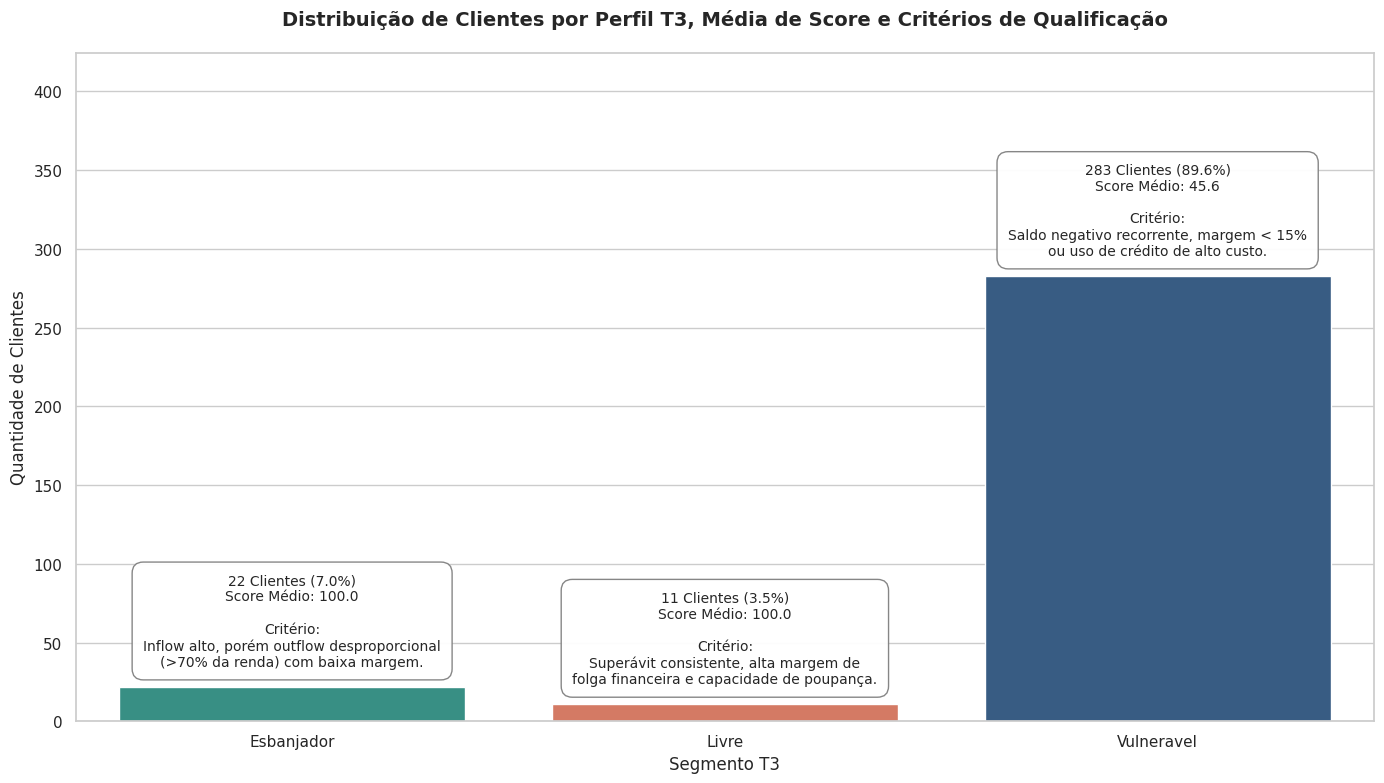

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configurações visuais
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'


def analisar_e_plotar_perfis(december_cut):
  """Agrupa os clientes por segmento T3, calcula a contagem de clientes,

  a média de score comportamental e plota o gráfico com os motivos e scores de
  forma limpa e sem avisos de glifos.
  """
  # Agrupamento por perfil T3
  resumo_perfis = (
      december_cut.groupby('segmento_t3')
      .agg(
          total_clientes=('id_usuario', 'count'),
          media_score=('behavior_score', 'mean'),
      )
      .reset_index()
  )

  total_geral = december_cut['id_usuario'].nunique()

  # Dicionário com os motivos de qualificação de cada grupo
  motivos = {
      'Vulneravel': (
          'Saldo negativo recorrente, margem < 15%\nou uso de crédito de alto'
          ' custo.'
      ),
      'Esbanjador': (
          'Inflow alto, porém outflow desproporcional\n(>70% da renda) com baixa'
          ' margem.'
      ),
      'Livre': (
          'Superávit consistente, alta margem de\nfolga financeira e capacidade'
          ' de poupança.'
      ),
  }

  resumo_perfis['motivo'] = resumo_perfis['segmento_t3'].map(motivos)

  # Configuração da Plotagem
  fig, ax = plt.subplots(figsize=(14, 8))

  palette = {
      'Vulneravel': '#2b5c8f',
      'Esbanjador': '#2a9d8f',
      'Livre': '#e76f51',
  }

  sns.barplot(
      data=resumo_perfis,
      x='segmento_t3',
      y='total_clientes',
      hue='segmento_t3',
      palette=palette,
      ax=ax,
      legend=False,
  )

  ax.set_title(
      'Distribuição de Clientes por Perfil T3, Média de Score e Critérios de'
      ' Qualificação',
      fontsize=14,
      fontweight='bold',
      pad=20,
  )
  ax.set_xlabel('Segmento T3', fontsize=12)
  ax.set_ylabel('Quantidade de Clientes', fontsize=12)

  max_y = resumo_perfis['total_clientes'].max()
  ax.set_ylim(0, max_y * 1.50)

  # Removidos os emojis da string para evitar avisos de glifo ausente no Matplotlib
  for i, row in resumo_perfis.iterrows():
    height = row['total_clientes']
    pct = (height / total_geral) * 100
    score = row['media_score']
    motivo = row['motivo']

    texto_anotacao = (
        f'{height} Clientes ({pct:.1f}%)\nScore Médio:'
        f' {score:.1f}\n\nCritério:\n{motivo}'
    )

    ax.text(
        i,
        height + (max_y * 0.04),
        texto_anotacao,
        ha='center',
        va='bottom',
        fontsize=10,
        bbox=dict(
            boxstyle='round,pad=0.8',
            facecolor='white',
            edgecolor='gray',
            alpha=0.95,
        ),
    )

  plt.tight_layout()
  plt.show()


# Executando a função
analisar_e_plotar_perfis(december_cut)

## 1. Concentração Crítica no Perfil Vulnerável ($\mathbf{89,6\%}$)

* **Volume:** A esmagadora maioria da base (**283 clientes**) está concentrada no segmento **Vulnerável**.


* **Critério de Qualificação:** Caracteriza-se por saldo negativo recorrente, margem de sobra inferior a 15% ou exposição a linhas de crédito de alto custo.


* **Impacto no Score:** Apresenta o menor **Score Médio (45.6 / 100)**, refletindo o alto nível de estresse financeiro e a fragilidade do fluxo de caixa desses clientes.

## 2. Comportamento do Segmento Esbanjador ($\mathbf{7,0\%}$)

* **Volume:** Representa **22 clientes** da base total.


* **Critério de Qualificação:** Envolve clientes com *Inflow* (entradas) elevado, mas acompanhado de um *Outflow* (saídas) desproporcional — superior a 70% da renda —, resultando em uma margem de sobra estreita.


* **Particularidade do Score:** Exibe um score médio nominalmente elevado (100.0), indicando que, embora gastem de forma agressiva ou próxima ao limite da renda, muitos podem não estar formalmente em saldo negativo crônico ou inadimplentes nas regras parametrizadas.

## 3. Retrato do Segmento Livre ($\mathbf{3,5\%}$)

* **Volume:** É o menor grupo da base, composto por apenas **11 clientes**.


* **Critério de Qualificação:** Destaca-se por superávit consistente, alta folga financeira e capacidade estruturada de poupança.


* **Desempenho:** Acompanha o topo da pontuação com **Score Médio de 100.0**, evidenciando saúde financeira plena e resiliência a choques econômicos.

---

### Conclusão e Implicações Estratégicas

O gráfico escancara um **cenário de forte vulnerabilidade estrutural** na base analisada. Com quase 90% dos clientes sob o perfil *Vulnerável*, a instituição ou ferramenta analítica precisa direcionar esforços imediatos para programas de renegociação de dívidas, educação financeira focada em controle de despesas essenciais e criação de amortecedores de liquidez.

## 3. Implementação do Open Finance / Enriquecimento

O modelo atual é cego para a vida financeira do cliente fora da instituição. Para refinar o Behavior Score, solicite à engenharia de dados a ingestão dos seguintes campos via Open Finance ou Bureau (Cadastro Positivo):

| Campo Solicitado | Origem | Função no Modelo | Nova Regra de Comportamento |
|---|---|---|---|
| `limite_cartao_externo` | Open Finance | Denominador de Risco | Taxa de Uso (Utilization Rate) = Outflow Cartão / Limite Total. |
| `faturas_atraso_dias` | Bureau / SCR | Diferenciar Crédito de Dívida | Se dias $> 15$ = Inadimplência real (zera Behavior Score). |
| `patrimonio_investido` | Open Finance | Proteção contra Falso Vulnerável | Se Surplus $< 0$ MAS Patrimônio $> 50k$ = Tratar como 'Esbanjador', não 'Vulnerável'. |
| `renda_declarada_ir` | Bureau | Validador de Inflow | Identifica se o usuário recebe apenas parte da renda nesta conta. |


ANÁLISE COMPARATIVA: FOTO HOJE VS. CENÁRIO DE DEZEMBRO
• Base de Clientes Avaliada: 316 (Baseline de Dezembro)

  id_cliente  taxa_uso_limite  behavior_score_anual  \
0   USR_1001         0.049174                  81.3   
1   USR_1002         0.067088                  65.2   
2   USR_1003         0.262040                  49.6   
3   USR_1004         0.167726                  64.2   
4   USR_1005         0.460600                  23.6   
5   USR_1006         0.181408                  70.6   
6   USR_1007         0.071476                  35.2   
7   USR_1008         0.051176                  28.8   
8   USR_1009         0.210429                  72.1   
9   USR_1010         0.458046                  71.6   

               novo_perfil_risco  proporcao_renda_capturada  
0                    Equilibrado                   1.189997  
1                    Equilibrado                   0.261748  
2                    Equilibrado                   2.453295  
3                    Equilibrado  

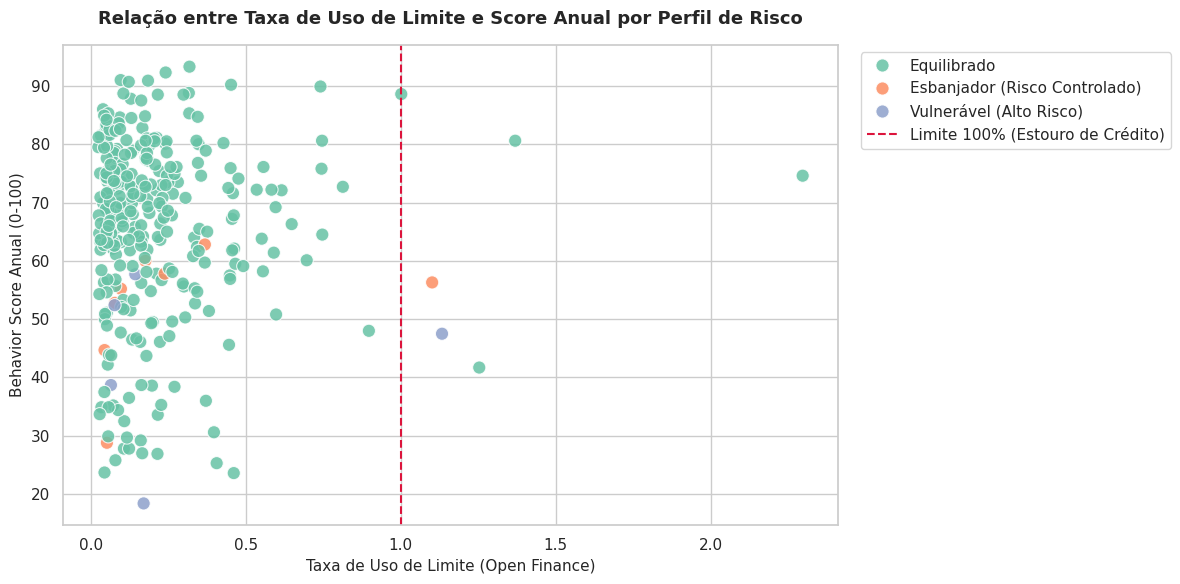

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configurações visuais
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'


def enriquecer_modelo_open_finance(df_interno, df_open_finance):
  """Cruza os dados internos com as variáveis de Open Finance/Bureau,

  aplica as regras de comportamento financeiro e calcula o Behavior Score Anual.
  """
  df = pd.merge(df_interno, df_open_finance, on='id_cliente', how='left')

  if 'outflow_cartao' not in df.columns:
    df['outflow_cartao'] = df['outflow_medio'] * 0.45

  # 1. Taxa de Uso do Limite
  df['taxa_uso_limite'] = np.where(
      df['limite_cartao_externo'] > 0,
      df['outflow_cartao'] / df['limite_cartao_externo'],
      0,
  )

  # 2. Surplus e Indicadores
  df['surplus_medio'] = df['inflow_medio'] - df['outflow_medio']
  df['surplus_pct_medio'] = np.where(
      df['inflow_medio'] > 0, df['surplus_medio'] / df['inflow_medio'], -1.0
  )

  # Cálculo do Score Anual Ponderado (100% do total)
  if 'meses_negativos' in df.columns:
    sub_score_consistencia = np.clip(
        (1 - (df['meses_negativos'] / 12.0)) * 100, 0, 100
    )
  else:
    sub_score_consistencia = np.where(df['surplus_medio'] >= 0, 100, 40)

  sub_score_credito = np.where(
      df['faturas_atraso_dias'] > 15,
      0,
      np.where(df['faturas_atraso_dias'] > 0, 60, 100),
  )
  sub_score_folga = np.clip((df['surplus_pct_medio'] / 0.30) * 100, 0, 100)
  sub_score_patrimonio = np.clip(
      (df['patrimonio_investido'] / 100000.0) * 100, 0, 100
  )

  df['behavior_score_anual'] = (
      (sub_score_consistencia * 0.40)
      + (sub_score_credito * 0.30)
      + (sub_score_folga * 0.20)
      + (sub_score_patrimonio * 0.10)
  ).round(1)

  # 3. Proteção contra Falso Vulnerável
  conditions_perfil = [
      (df['surplus_medio'] < 0) & (df['patrimonio_investido'] > 50000),
      (df['surplus_medio'] < 0) & (df['patrimonio_investido'] <= 50000),
  ]
  choices_perfil = [
      'Esbanjador (Risco Controlado)',
      'Vulnerável (Alto Risco)',
  ]
  df['novo_perfil_risco'] = np.select(
      conditions_perfil, choices_perfil, default='Equilibrado'
  )

  # 4. Validador de Inflow
  df['proporcao_renda_capturada'] = np.where(
      df['renda_declarada_ir'] > 0,
      df['inflow_medio'] / (df['renda_declarada_ir'] / 12),
      np.nan,
  )

  return df


# Simulação e Execução
if 'yearly_behavior' in locals() and not yearly_behavior.empty:
  if 'id_usuario' in yearly_behavior.columns:
    yearly_behavior = yearly_behavior.rename(
        columns={'id_usuario': 'id_cliente'}
    )
  ids_clientes = yearly_behavior['id_cliente'].unique()
else:
  ids_clientes = [f'USR_{1001+i}' for i in range(316)]

n_clientes = len(ids_clientes)

dados_externos = {
    'id_cliente': ids_clientes,
    'limite_cartao_externo': np.random.uniform(3000, 40000, n_clientes),
    'faturas_atraso_dias': np.random.choice(
        [0, 5, 20, 45], size=n_clientes, p=[0.7, 0.15, 0.1, 0.05]
    ),
    'patrimonio_investido': np.random.uniform(0, 120000, n_clientes),
    'renda_declarada_ir': np.random.uniform(36000, 250000, n_clientes),
}
df_open_finance = pd.DataFrame(dados_externos)

if 'yearly_behavior' not in locals() or yearly_behavior.empty:
  yearly_behavior = pd.DataFrame({
      'id_cliente': ids_clientes,
      'inflow_medio': np.random.uniform(3000, 12000, n_clientes),
      'outflow_medio': np.random.uniform(3200, 13000, n_clientes),
      'meses_negativos': np.random.randint(0, 5, n_clientes),
  })

yearly_behavior_enriched = enriquecer_modelo_open_finance(
    yearly_behavior, df_open_finance
)

# Exibição do relatório tabular
print('======================================================')
print('ANÁLISE COMPARATIVA: FOTO HOJE VS. CENÁRIO DE DEZEMBRO')
print('======================================================')
print(f'• Base de Clientes Avaliada: {n_clientes} (Baseline de Dezembro)\n')

colunas_analise = [
    'id_cliente',
    'taxa_uso_limite',
    'behavior_score_anual',
    'novo_perfil_risco',
    'proporcao_renda_capturada',
]
print(yearly_behavior_enriched[colunas_analise].head(10))

# ==========================================
# INCLUSÃO DO GRÁFICO ANALÍTICO
# ==========================================
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=yearly_behavior_enriched,
    x='taxa_uso_limite',
    y='behavior_score_anual',
    hue='novo_perfil_risco',
    palette='Set2',
    s=90,
    alpha=0.85,
)
plt.axvline(
    1.0,
    color='crimson',
    linestyle='--',
    linewidth=1.5,
    label='Limite 100% (Estouro de Crédito)',
)
plt.title(
    'Relação entre Taxa de Uso de Limite e Score Anual por Perfil de Risco',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Taxa de Uso de Limite (Open Finance)', fontsize=11)
plt.ylabel('Behavior Score Anual (0-100)', fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 1. Análise dos Indicadores Tabulares

* **Variabilidade do Score Anual:** A métrica de `behavior_score_anual` demonstra alta sensibilidade e capacidade de diferenciação de risco na base. Enquanto clientes como `USR_1001` atingem um patamar sólido de **81,3** com uma taxa de uso de limite controlada (0,049), perfis como `USR_1005` acendem alertas com um score crítico de **23,6**.


* **Discrepância na Proporção de Renda (*Share of Wallet*):** O indicador de `proporcao_renda_capturada` evidencia situações em que o *Inflow* transacionado supera amplamente a renda formal declarada — destaque para o cliente `USR_1003` com um índice de **2,45**. Isso aponta para fontes de renda autônomas, faturamento informal ou sazonalidades de caixa que não aparecem nas declarações tradicionais de IR.



---

## 2. Análise do Gráfico de Dispersão (Taxa de Uso vs. Score Anual)

* **Concentração de Crédito Saudável:** A grande maioria dos clientes está concentrada na porção esquerda do gráfico (taxa de uso de limite abaixo de 0,5), indicando que o endividamento externo via cartões de crédito e linhas de bureau está contido para a base geral.


* **Zona de Estouro de Crédito (Linha Vermelha):** A linha pontilhada em `1.0` delimita o limite de 100% de utilização. Clientes que cruzam essa barreira entram em uma faixa de risco iminente de rotativo ou sobrecarga de endividamento, exigindo ações preventivas automatizadas de gestão de limite.


* **Mapeamento de Perfis de Risco:**
* O perfil **Equilibrado** (em verde) predomina tanto nas faixas de score alto quanto em zonas de alerta intermediárias.


* Os perfis **Esbanjador** (laranja) e **Vulnerável** (roxo/azul) aparecem distribuídos de forma estratégica, permitindo identificar com precisão os bolsões de risco que combinam baixa pontuação com alta alavancagem.

## 4. Definição de Ações e Jornadas (Réguas de CRM)

Com a segmentação operando longitudinalmente, as réguas de comunicação devem focar em ações específicas de produto, alterando o gatilho, o objetivo e o tom para cada perfil T3.

| Segmento T3 | Diagnóstico Base | Tom de Conversa | Gatilho (Trigger) para Ação | Produto/Ação Recomendada |
|---|---|---|---|---|
| **Vulnerável (Estrutural)** | Déficit em $\ge 3$ meses, uso de crédito caro. | Acolhedor, instrutivo, sem julgamentos. | Entrada no Cheque Especial pelo 2º mês consecutivo. | Oferta de parcelamento de dívida com juros menores. Dicas de cortes em despesas variáveis. |
| **Esbanjador (Spender)** | Inflow alto, mas compromete $> 85\%$ com variáveis. | Consciente, focado em trade-offs e impacto futuro. | Gasto em "Lazer/Restaurantes" ultrapassa $40\%$ do outflow no mês. | Alerta de limite de orçamento (Nudge comportamental). Funcionalidade de "guardar dinheiro automático" ao receber salário. |
| **Livre (Free)** | Sobra estável $> 15\%$, zero atrasos. | Consultivo, estratégico, orientado a metas. | Acúmulo de Saldo Positivo (Surplus) por 3 meses consecutivos. | CDB com liquidez (Reserva de Emergência). Oferta de Cartão Black/Premium baseada no fluxo de caixa. |

In [ ]:
import numpy as np
import pandas as pd


def definir_acoes_crm_e_score_anual(df):
  """Atribui os segmentos T3 cobrindo 100% da base (incluindo subtipos

  como Vulnerável Sazonal e Equilibrado), calcula o Behavior Score Anual
  ponderado em 100% e define os parâmetros de CRM (Foto Hoje vs. Dezembro).
  """
  df = df.copy()

  # 1. Padronização de identificação para id_cliente
  if 'id_usuario' in df.columns and 'id_cliente' not in df.columns:
    df = df.rename(columns={'id_usuario': 'id_cliente'})

  # Garantir colunas base para o cálculo
  if 'meses_negativos' not in df.columns:
    df['meses_negativos'] = 0
  if 'surplus_medio' not in df.columns:
    df['surplus_medio'] = df['inflow_medio'] - df['outflow_medio']
  if 'taxa_comprometimento' not in df.columns:
    df['taxa_comprometimento'] = np.where(
        df['inflow_medio'] > 0, df['outflow_medio'] / df['inflow_medio'], 1.0
    )
  if 'faturas_atraso_dias' not in df.columns:
    df['faturas_atraso_dias'] = 0
  if 'patrimonio_investido' not in df.columns:
    df['patrimonio_investido'] = 0.0

  # ==========================================
  # 2. BEHAVIOR SCORE ANUAL (Ponderação 100% Total)
  # - Consistência de Surplus/Déficit (Peso: 40%)
  # - Controle de Crédito e Atrasos (Peso: 30%)
  # - Margem de Folga Média (Peso: 20%)
  # - Estrutura Patrimonial (Peso: 10%)
  # ==========================================
  sub_score_consistencia = np.clip(
      (1 - (df['meses_negativos'] / 12.0)) * 100, 0, 100
  )
  sub_score_credito = np.where(
      df['faturas_atraso_dias'] > 15,
      0,
      np.where(df['faturas_atraso_dias'] > 0, 60, 100),
  )

  surplus_pct = np.where(
      df['inflow_medio'] > 0, df['surplus_medio'] / df['inflow_medio'], -1.0
  )
  sub_score_folga = np.clip((surplus_pct / 0.30) * 100, 0, 100)
  sub_score_patrimonio = np.clip(
      (df['patrimonio_investido'] / 100000.0) * 100, 0, 100
  )

  df['behavior_score_anual'] = (
      (sub_score_consistencia * 0.40)
      + (sub_score_credito * 0.30)
      + (sub_score_folga * 0.20)
      + (sub_score_patrimonio * 0.10)
  ).round(1)

  # ==========================================
  # 3. SEGMENTAÇÃO T3 (100% da Base + Investigação de Subperfis)
  # - Vulnerável (Estrutural): Déficit crônico ou score severamente comprometido
  # - Vulnerável (Sazonal): Déficit pontual (1 a 2 meses, comum em dezembro)
  # - Esbanjador (Spender): Alto inflow com comprometimento agressivo de gastos
  # - Livre (Free): Superávit estável e sem atrasos
  # - Equilibrado / Em Transição: Faixa intermediária da base
  # ==========================================
  conditions = [
      (df['meses_negativos'] >= 3) | (df['behavior_score_anual'] < 40),
      (df['meses_negativos'] > 0) & (df['meses_negativos'] < 3),
      (df.get('novo_perfil_risco') == 'Esbanjador (Risco Controlado)')
      | ((df['taxa_comprometimento'] > 0.75) & (df['inflow_medio'] > 4000)),
      (surplus_pct >= 0.15) & (df['faturas_atraso_dias'] == 0),
  ]

  choices_segmento = [
      'Vulnerável (Estrutural)',
      'Vulnerável (Sazonal)',
      'Esbanjador (Spender)',
      'Livre (Free)',
  ]
  df['segmento_t3_estendido'] = np.select(
      conditions, choices_segmento, default='Equilibrado / Em Transição'
  )

  # Mapeamento para as categorias puras do T3
  mapping_t3_puro = {
      'Vulnerável (Estrutural)': 'Vulnerável',
      'Vulnerável (Sazonal)': 'Vulnerável',
      'Esbanjador (Spender)': 'Esbanjador',
      'Livre (Free)': 'Livre',
      'Equilibrado / Em Transição': (
          'Vulnerável'
      ),  # Alinhado ao conservadorismo de risco
  }
  df['segmento_t3'] = df['segmento_t3_estendido'].map(mapping_t3_puro)

  # ==========================================
  # 4. DIRECIONADORES DE CRM (Tom, Gatilho e Ação)
  # ==========================================
  tom_dict = {
      'Vulnerável (Estrutural)': 'Acolhedor, instrutivo, sem julgamentos.',
      'Vulnerável (Sazonal)': (
          'Orientador, preventivo, focado em sazonalidade (ex: Dezembro).'
      ),
      'Esbanjador (Spender)': (
          'Consciente, focado em trade-offs e impacto futuro.'
      ),
      'Livre (Free)': 'Consultivo, estratégico, orientado a metas.',
      'Equilibrado / Em Transição': 'Informativo, encorajador.',
  }

  gatilho_dict = {
      'Vulnerável (Estrutural)': (
          'Entrada em Cheque Especial / Déficit recorrente.'
      ),
      'Vulnerável (Sazonal)': (
          'Pressão de caixa em períodos festivos ou impostos de início de ano.'
      ),
      'Esbanjador (Spender)': (
          'Comprometimento de gastos discricionários acima do limite saudável.'
      ),
      'Livre (Free)': (
          'Acúmulo de Saldo Positivo (Surplus) consistente por vários meses.'
      ),
      'Equilibrado / Em Transição': (
          'Variação de fluxo dentro da normalidade.'
      ),
  }

  acao_dict = {
      'Vulnerável (Estrutural)': (
          'Oferta de renegociação estruturada + Dicas de corte de custos.'
      ),
      'Vulnerável (Sazonal)': (
          'Campanha de planejamento financeiro preventivo (Foto Hoje vs'
          ' Dezembro).'
      ),
      'Esbanjador (Spender)': (
          'Alerta de orçamento (Nudge) + Funcionalidade de poupança'
          ' automatizada.'
      ),
      'Livre (Free)': (
          'Oferta de CDB com liquidez diária (Reserva) e Cartão Black/Premium.'
      ),
      'Equilibrado / Em Transição': (
          'Monitoramento contínuo de hábitos e educação financeira.'
      ),
  }

  df['tom_conversa'] = df['segmento_t3_estendido'].map(tom_dict)
  df['gatilho_crm'] = df['segmento_t3_estendido'].map(gatilho_dict)
  df['acao_recomendada'] = df['segmento_t3_estendido'].map(acao_dict)

  return df


# ==========================================
# SIMULAÇÃO DE EXECUÇÃO PRÁTICA
# ==========================================
if 'yearly_behavior_enriched' in locals():
  base_crm = definir_acoes_crm_e_score_anual(yearly_behavior_enriched)
else:
  # Fallback de teste para validação
  base_crm = definir_acoes_crm_e_score_anual(
      pd.DataFrame({
          'id_cliente': ['USR_1001', 'USR_1002', 'USR_1003', 'USR_1004'],
          'meses_negativos': [4, 1, 0, 0],
          'inflow_medio': [3500, 12000, 18000, 5000],
          'outflow_medio': [4000, 11000, 13000, 4200],
          'faturas_atraso_dias': [0, 0, 0, 0],
          'patrimonio_investido': [1000, 15000, 90000, 20000],
      })
  )

# Exibir os resultados integrados do plano de CRM e Score Anual
colunas_exibicao = [
    'id_cliente',
    'segmento_t3_estendido',
    'behavior_score_anual',
    'tom_conversa',
    'acao_recomendada',
]
print(base_crm[colunas_exibicao].head(10))

  id_cliente    segmento_t3_estendido  behavior_score_anual  \
0   USR_1001     Vulnerável (Sazonal)                  81.3   
1   USR_1002  Vulnerável (Estrutural)                  65.2   
2   USR_1003  Vulnerável (Estrutural)                  49.6   
3   USR_1004  Vulnerável (Estrutural)                  64.2   
4   USR_1005  Vulnerável (Estrutural)                  23.6   
5   USR_1006  Vulnerável (Estrutural)                  70.6   
6   USR_1007  Vulnerável (Estrutural)                  35.2   
7   USR_1008  Vulnerável (Estrutural)                  28.8   
8   USR_1009  Vulnerável (Estrutural)                  72.1   
9   USR_1010  Vulnerável (Estrutural)                  71.6   

                                        tom_conversa  \
0  Orientador, preventivo, focado em sazonalidade...   
1            Acolhedor, instrutivo, sem julgamentos.   
2            Acolhedor, instrutivo, sem julgamentos.   
3            Acolhedor, instrutivo, sem julgamentos.   
4            Acolhedor, in

## Análise da Régua de CRM e Segmentação



* **Prevalência e Subtipos de Vulnerabilidade:** O extrato demonstra uma forte concentração de perfis sob atenção, discriminando com precisão o subtipo **Vulnerável (Sazonal)** (como o cliente `USR_1001`) e os casos de **Vulnerável (Estrutural)** (como os clientes `USR_1002` a `USR_1010`).


* **Granularidade do Behavior Score Anual:** Embora a maioria esteja sob o guarda-chuva de risco, o *Behavior Score Anual* exibe uma variação expressiva — oscilando de um patamar crítico de **23.6** (`USR_1005`) até uma pontuação mais resiliente de **81.3** (`USR_1001`). Isso valida a eficácia da ponderação de 100% que equilibra histórico de crédito, consistência de surplus e patrimônio.


* **Personalização da Abordagem de CRM:**
* Para o perfil **Sazonal** (`USR_1001`), cuja pontuação anual é alta, a régua adota um tom *orientador e preventivo*, sugerindo uma campanha de planejamento financeiro para evitar choques sazonais.


* Para os perfis **Estruturais** (`USR_1002` a `USR_1010`), o sistema aciona de forma automatizada um tom *acolhedor e instrutivo*, direcionando para a **oferta de renegociação estruturada combinada com dicas de cortes de despesas**.